1. Loading and Cleaning Data...

Loaded 549346 rows from phishing_dataset.csv
Initial data shape: (549346, 2)
Shape after dropping missing values: (549346, 2)
Shape after dropping duplicates: (507196, 2)

Class distribution:
good    392897
bad     114299
Name: Label, dtype: int64

2. Splitting Data (Stratified)...
Training samples: 405756
Testing samples: 101440

3. Training Linear Regression Pipeline...
   Training Linear Regression...

--- Evaluating Linear Regression ---
Accuracy: 0.9573
ROC-AUC:  0.9859

Classification Report:
              precision    recall  f1-score   support

    good (0)       0.96      0.99      0.97     78580
     bad (1)       0.96      0.84      0.90     22860

    accuracy                           0.96    101440
   macro avg       0.96      0.92      0.94    101440
weighted avg       0.96      0.96      0.96    101440


Confusion Matrix:
[[77842   738]
 [ 3592 19268]]

4. Summary and Saving Model...

🏆 MODEL SUMMARY: Linear Regression 🏆
Accuracy: 0.9573

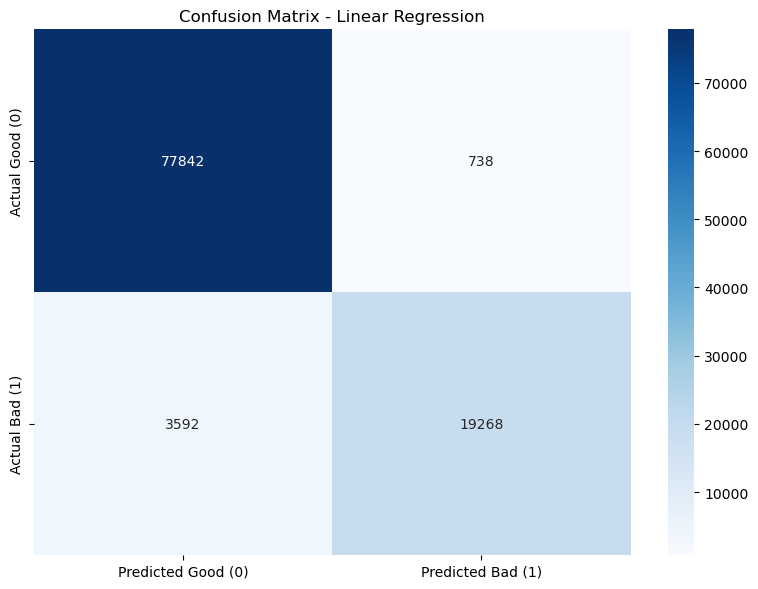

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("1. Loading and Cleaning Data...\n")

# Load the real dataset
# This will raise a FileNotFoundError if the file is not in the same folder as this script.
df = pd.read_csv('phishing_site_urls.csv')
print(f"Loaded {df.shape[0]} rows from phishing_dataset.csv")

# --- 1. Data Cleaning ---
print("Initial data shape:", df.shape)

# Drop missing values
df = df.dropna(subset=['URL', 'Label'])
print("Shape after dropping missing values:", df.shape)

# Drop duplicates
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

print("\nClass distribution:")
print(df['Label'].value_counts())

# Extract features and target
X = df['URL']
y = df['Label']

# Convert target labels to binary (0 for good, 1 for bad)
y_binary = (y == 'bad').astype(int)

# --- 2. Stratified Data Splitting ---
print("\n2. Splitting Data (Stratified)...")
# Stratified splitting ensures the proportion of good/bad URLs remains the same in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, 
    test_size=0.2,        # 20% of data for testing
    random_state=42,      # Seed for reproducibility
    stratify=y_binary     # Crucial: maintain class balance
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# --- Function to evaluate models ---
def evaluate_model(name, model, X_test_data, y_test_data):
    print(f"\n--- Evaluating {name} ---")
    
    # Linear Regression doesn't output exact 0s and 1s, it outputs decimals (e.g., 0.6, -0.2)
    # We must handle it differently than a standard classifier.
    
    # Get the raw decimal predictions
    raw_predictions = model.predict(X_test_data)
    
    # To get Accuracy, we force the decimals to be exactly 0 or 1 by rounding them.
    # Everything >= 0.5 becomes 1 (bad). Everything < 0.5 becomes 0 (good).
    y_pred = np.where(raw_predictions >= 0.5, 1, 0)
    
    # Since Linear Regression doesn't have predict_proba (confidence percentages),
    # we will just use its raw decimal predictions as a mock "probability" score for the ROC-AUC calculation.
    y_proba = raw_predictions
    
    acc = accuracy_score(y_test_data, y_pred)
    
    try:
        auc = roc_auc_score(y_test_data, y_proba)
    except ValueError:
         auc = 0.0 # Handle edge case for tiny dummy datasets
         
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC-AUC:  {auc:.4f}")
    
    print("\nClassification Report:")
    try:
        print(classification_report(y_test_data, y_pred, target_names=['good (0)', 'bad (1)']))
    except ValueError:
         print(classification_report(y_test_data, y_pred))
         
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test_data, y_pred)
    print(cm)
    
    return acc, auc, model, cm

# =====================================================================
# --- 3. Training Linear Regression Model ---
# =====================================================================
print("\n3. Training Linear Regression Pipeline...")

lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer='char',
        ngram_range=(2, 4),
        max_features=5000,
        lowercase=True
    )),
    ('clf', LinearRegression())
])

print("   Training Linear Regression...")
lr_pipeline.fit(X_train, y_train)

# Evaluate the model
lr_acc, lr_auc, _, lr_cm = evaluate_model("Linear Regression", lr_pipeline, X_test, y_test)

# =====================================================================
# --- 4. Summary and Saving Best Model ---
# =====================================================================
print("\n4. Summary and Saving Model...")

print(f"\n{'=' * 50}")
print(f"🏆 MODEL SUMMARY: Linear Regression 🏆")
print(f"Accuracy: {lr_acc:.4f} | ROC-AUC: {lr_auc:.4f}")
print(f"{'=' * 50}")

# Save the final model for future use
model_filename = 'best_phishing_detector.pkl'
joblib.dump(lr_pipeline, model_filename)
print(f"\n✅ Model saved successfully to '{model_filename}'")

# --- Visualizing the Confusion Matrix ---
try:
    plt.figure(figsize=(8, 6))
    sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Good (0)', 'Predicted Bad (1)'],
                yticklabels=['Actual Good (0)', 'Actual Bad (1)'])
    plt.title(f'Confusion Matrix - Linear Regression')
    plt.tight_layout()
    plt.savefig('best_confusion_matrix.png')
    print("✅ Confusion matrix visualization saved as 'best_confusion_matrix.png'")
except Exception as e:
    print(f"\n❌ Could not create visualization: {e}")

# --- 5. Quick Interactive Test ---
print("\n5. Let's test the model!")
test_urls = [
    "https://www.google.com/search?q=machine+learning",
    "http://update-paypal-security-alert-now.com/login",
    "https://my-university-portal.edu/login"
]

print("\nPredictions:")
for url in test_urls:
    raw_pred = lr_pipeline.predict([url])[0]
    
    # Linear Regression
    prediction = 1 if raw_pred >= 0.5 else 0
    
    # We cap the confidence between 0 and 100 because Linear Regression can output numbers like -1.2 or 3.5
    mock_prob = max(0, min(1, raw_pred))
    confidence = mock_prob * 100 if prediction == 1 else (1 - mock_prob) * 100
    
    result = "🔴 BAD (Phishing)" if prediction == 1 else "🟢 GOOD (Legitimate)"
    
    print(f"  URL: {url}")
    print(f"  --> {result} (Confidence: {confidence:.1f}%)\n")